# Using KNN Machine Learning Model


# Importing the libaries

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix


# loading the dataset from the csv.file

In [4]:
# 1. Load Data
df = pd.read_csv('sonar.csv', header=None)
print(df.describe())
print(df.head())
X = df.drop(60, axis=1) # The 60 sonar frequencies
y = df[60]              # Target label: 'M' (Mine) or 'R' (Rock)

               0           1           2           3           4           5   \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.029164    0.038437    0.043832    0.053892    0.075202    0.104570   
std      0.022991    0.032960    0.038428    0.046528    0.055552    0.059105   
min      0.001500    0.000600    0.001500    0.005800    0.006700    0.010200   
25%      0.013350    0.016450    0.018950    0.024375    0.038050    0.067025   
50%      0.022800    0.030800    0.034300    0.044050    0.062500    0.092150   
75%      0.035550    0.047950    0.057950    0.064500    0.100275    0.134125   
max      0.137100    0.233900    0.305900    0.426400    0.401000    0.382300   

               6           7           8           9   ...          50  \
count  208.000000  208.000000  208.000000  208.000000  ...  208.000000   
mean     0.121747    0.134799    0.178003    0.208259  ...    0.016069   
std      0.061788    0.085152    0.118387    0.1

In [18]:
# 2. Preprocessing
# Convert text labels ('M', 'R') to numbers (0, 1)
le = LabelEncoder()
y = le.fit_transform(y)

df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

# Splitting the data 70/30 rule

In [6]:
# Split into Training (70%) and Testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the signal data (crucial for KNN performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training the Model

In [7]:
# 3. Train Model (K=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 4. Results
predictions = knn.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 92.06%


# Generating Visulization Slide

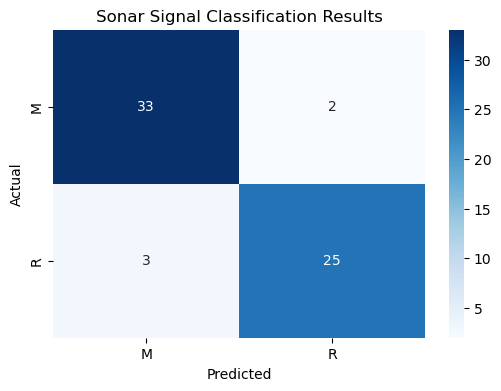

In [8]:
# 5. Generate Plot for Visualization Slide
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Sonar Signal Classification Results')
plt.savefig('confusion_matrix.png')

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load Data
df = pd.read_csv('sonar.csv', header=None)
X = df.drop(60, axis=1) # The 60 sonar frequencies
y = df[60]              # Target label: 'M' (Mine) or 'R' (Rock)

# 2. Preprocessing
# Convert text labels ('M', 'R') to numbers (0, 1)
le = LabelEncoder()
y = le.fit_transform(y)

# Split into Training (70%) and Testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the signal data (crucial for KNN performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Train Model (K=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 4. Results
predictions = knn.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

 



Model Accuracy: 92.06%


# Model without user input func

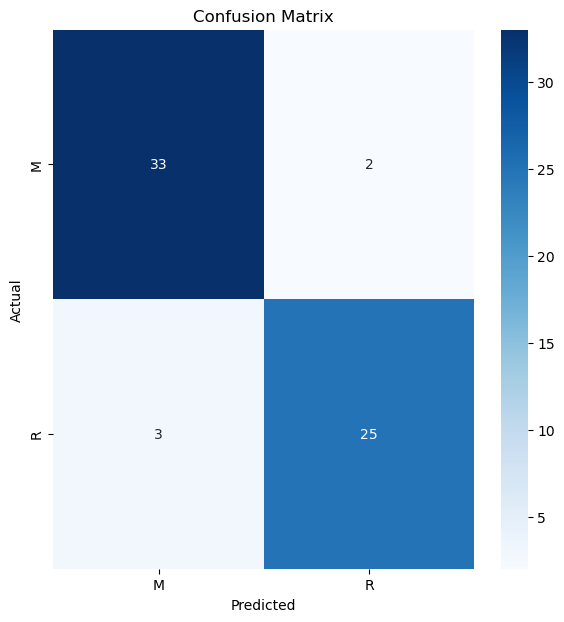

In [5]:
import tkinter as tk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

class SonarGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Sonar Rock vs Mine Classifier")
        self.root.geometry("1000x700") # Increased size slightly to fit new controls

        # --- 1. Data & Model Initialization ---
        self.load_and_train_model()

        # --- 2. GUI Layout ---
        
        # Left Side: Controls
        self.control_frame = tk.Frame(root, padx=20, pady=20, bg="#f0f0f0")
        self.control_frame.pack(side=tk.LEFT, fill=tk.Y)

        tk.Label(self.control_frame, text="Control Panel", font=("Arial", 16, "bold"), bg="#f0f0f0").pack(pady=10)

        # Accuracy Label
        self.acc_label = tk.Label(self.control_frame, text=f"Model Accuracy:\n{self.accuracy*100:.2f}%", 
                                  font=("Arial", 14), fg="green", bg="#f0f0f0")
        self.acc_label.pack(pady=10)

        # --- EXISTING: Random Test Button ---
        tk.Label(self.control_frame, text="--- Random Test ---", bg="#f0f0f0", fg="gray").pack(pady=5)
        self.btn_predict = tk.Button(self.control_frame, text="Pick Random Sample", 
                                     command=self.predict_random_sample, 
                                     font=("Arial", 11), bg="#2196F3", fg="white", width=25)
        self.btn_predict.pack(pady=5)

        # --- NEW: User Input Section ---
        tk.Label(self.control_frame, text="--- Custom Input ---", bg="#f0f0f0", fg="gray").pack(pady=(20, 5))
        
        tk.Label(self.control_frame, text="Paste 60 comma-separated values:", 
                 bg="#f0f0f0", font=("Arial", 9)).pack()
        
        # Entry box for user input
        self.entry_input = tk.Entry(self.control_frame, width=30, font=("Arial", 10))
        self.entry_input.pack(pady=5)
        
        # Button to trigger custom prediction
        self.btn_custom = tk.Button(self.control_frame, text="Predict Custom Data", 
                                     command=self.predict_custom_input, 
                                     font=("Arial", 11), bg="#FF9800", fg="white", width=25)
        self.btn_custom.pack(pady=5)

        # Helper button to fill entry with example data (optional but helpful)
        self.btn_fill = tk.Button(self.control_frame, text="Paste Example Data", 
                                     command=self.fill_example_data, 
                                     font=("Arial", 8), bg="#ddd")
        self.btn_fill.pack(pady=2)

        # --- Result Display Area ---
        tk.Label(self.control_frame, text="Prediction Result:", font=("Arial", 12, "bold"), bg="#f0f0f0").pack(pady=(30, 5))
        self.result_text = tk.StringVar()
        self.result_text.set("Ready...")
        self.lbl_result = tk.Label(self.control_frame, textvariable=self.result_text, 
                                   font=("Arial", 14), bg="white", width=25, height=3, relief="sunken")
        self.lbl_result.pack()

        # Right Side: Visualization
        self.plot_frame = tk.Frame(root, bg="white")
        self.plot_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.draw_confusion_matrix()

    def load_and_train_model(self):
        try:
            # Load Data (Ensure sonar.csv is in the same folder)
            df = pd.read_csv('sonar.csv', header=None)
            X = df.drop(60, axis=1)
            y = df[60]

            # Preprocessing
            self.le = LabelEncoder()
            y = self.le.fit_transform(y) 
            self.class_names = self.le.classes_ 

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

            # Scaling
            self.scaler = StandardScaler()
            self.X_train_scaled = self.scaler.fit_transform(X_train)
            self.X_test_scaled = self.scaler.transform(X_test)
            self.y_test = y_test

            # Training
            self.knn = KNeighborsClassifier(n_neighbors=3)
            self.knn.fit(self.X_train_scaled, y_train)

            # Evaluation
            predictions = self.knn.predict(self.X_test_scaled)
            self.accuracy = accuracy_score(y_test, predictions)
            self.cm = confusion_matrix(y_test, predictions)
            
            # Save test set for random sampling in GUI
            self.X_test_raw = X_test 
            self.y_test_raw = y_test

        except Exception as e:
            messagebox.showerror("Error", f"Could not load data: {e}")
            self.root.destroy()

    def draw_confusion_matrix(self):
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(self.cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=self.class_names, yticklabels=self.class_names, ax=ax)
        ax.set_title('Confusion Matrix')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')

        canvas = FigureCanvasTkAgg(fig, master=self.plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    def predict_random_sample(self):
        # Pick a random index from the test set
        random_idx = np.random.choice(self.X_test_raw.index)
        
        # Get the features and actual label
        sample_features = self.X_test_raw.loc[random_idx].values.reshape(1, -1)
        
        # We need the integer location of the index to find the matching y value
        loc_idx = self.X_test_raw.index.get_loc(random_idx)
        actual_label_idx = self.y_test_raw[loc_idx] 
        actual_label_str = self.class_names[actual_label_idx]

        # Scale and Predict
        sample_scaled = self.scaler.transform(sample_features)
        prediction_idx = self.knn.predict(sample_scaled)[0]
        prediction_str = self.class_names[prediction_idx]

        # Update Display
        result_msg = f"Mode: Random Test\nPredicted: {prediction_str}\nActual: {actual_label_str}"
        self.result_text.set(result_msg)
        
        if prediction_str == actual_label_str:
            self.lbl_result.config(fg="green")
        else:
            self.lbl_result.config(fg="red")

    def fill_example_data(self):
        """Helper to put valid data into the box so user sees format"""
        # Take the first row of test data just as an example
        example_data = self.X_test_raw.iloc[0].values
        # Convert to string separated by commas
        data_str = ", ".join(map(str, example_data))
        
        self.entry_input.delete(0, tk.END)
        self.entry_input.insert(0, data_str)

    def predict_custom_input(self):
        raw_text = self.entry_input.get()
        
        if not raw_text:
            messagebox.showwarning("Input Error", "Please enter data first.")
            return

        try:
            # 1. Parse the string into a list of floats
            # We split by comma and strip whitespace
            input_list = [float(x.strip()) for x in raw_text.split(',')]

            # 2. Check if we have exactly 60 features
            if len(input_list) != 60:
                messagebox.showerror("Input Error", f"Expected 60 values, but got {len(input_list)}.\nPlease verify your input.")
                return

            # 3. Convert to numpy array and reshape
            input_array = np.array(input_list).reshape(1, -1)

            # 4. SCALE THE DATA (Crucial Step!)
            # The model was trained on scaled data, so we must scale the input
            input_scaled = self.scaler.transform(input_array)

            # 5. Predict
            prediction_idx = self.knn.predict(input_scaled)[0]
            prediction_str = self.class_names[prediction_idx]

            # 6. Update Display
            # Note: We don't know the 'Actual' label for custom input
            self.result_text.set(f"Mode: Custom Input\nPredicted: {prediction_str}")
            self.lbl_result.config(fg="blue")

        except ValueError:
            messagebox.showerror("Format Error", "Input must be numbers separated by commas.\nExample: 0.02, 0.55, 1.2...")

# --- Main Application Loop ---
if __name__ == "__main__":
    root = tk.Tk()
    app = SonarGUI(root)
    root.mainloop()

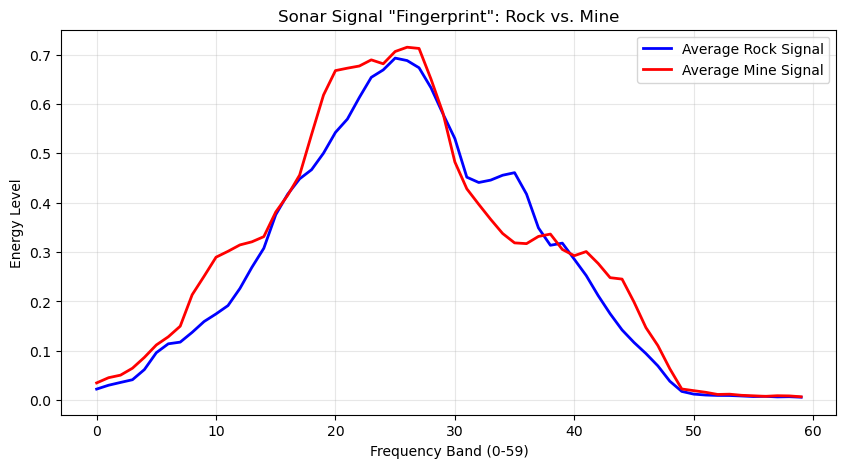

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('sonar.csv', header=None)

# 2. Calculate the average signal for Rocks vs. Mines
rock_avg = df[df[60] == 'R'].drop(60, axis=1).mean()
mine_avg = df[df[60] == 'M'].drop(60, axis=1).mean()

# 3. Plot
plt.figure(figsize=(10, 5))
plt.plot(rock_avg, label='Average Rock Signal', color='blue', linewidth=2)
plt.plot(mine_avg, label='Average Mine Signal', color='red', linewidth=2)

plt.title('Sonar Signal "Fingerprint": Rock vs. Mine')
plt.xlabel('Frequency Band (0-59)')
plt.ylabel('Energy Level')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Save
plt.savefig('signal_comparison.png')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_13556\1122887336.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[60], palette={'M': 'red', 'R': 'blue'})


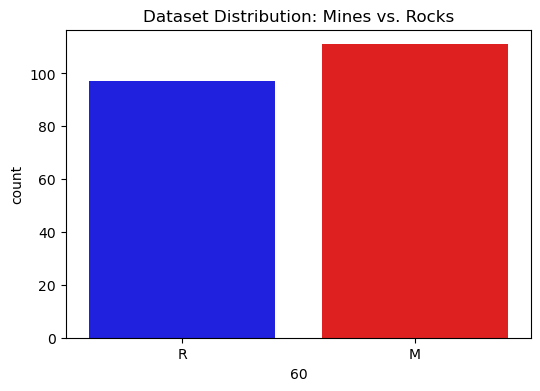

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x=df[60], palette={'M': 'red', 'R': 'blue'})
plt.title('Dataset Distribution: Mines vs. Rocks')
plt.savefig('class_distribution.png')
plt.show()
